# Libary yang digunakan


In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
import os

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-Learn & Hugging Face
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from transformers import pipeline
from tqdm import tqdm

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

tf.random.set_seed(0)
np.random.seed(0)

In [143]:
# ==========================================
# 1. DEFINISI SAHAM LQ45, SEKTOR & KATA KUNCI
# ==========================================
# Ini adalah representasi saham LQ45 dari berbagai sektor.

lq45_data = {
    'BBRI.JK': {'sektor': 'Keuangan', 'keywords': ['bbri', ' bri ', 'bank rakyat indonesia']},
    'BMRI.JK': {'sektor': 'Keuangan', 'keywords': ['bmri', ' mandiri ', 'bank mandiri']},
    'BBCA.JK': {'sektor': 'Keuangan', 'keywords': ['bbca', ' bca ', 'bank central asia']},
    'BBNI.JK': {'sektor': 'Keuangan', 'keywords': ['bbni', ' bni ', 'bank negara indonesia']},
    'TLKM.JK': {'sektor': 'Infrastruktur', 'keywords': ['tlkm', ' telkom ']},
    'PGAS.JK': {'sektor': 'Infrastruktur', 'keywords': ['pgas', 'perusahaan gas', ' pgn ']},
    'ASII.JK': {'sektor': 'Konsumer Non-Primer', 'keywords': ['asii', ' astra ']},
    'ICBP.JK': {'sektor': 'Konsumer Primer', 'keywords': ['icbp', 'indofood']},
    'UNTR.JK': {'sektor': 'Industri', 'keywords': ['untr', 'united tractors']}
}

tickers = list(lq45_data.keys())
start_date = "2021-01-01"
end_date = "2026-03-31"

print("=== TAHAP 1: SKRINING PERFORMA SAHAM LQ45 ===")
print(f"Mengunduh data {len(tickers)} saham dari {start_date} hingga {end_date}...\n")

df_bulk = yf.download(tickers, start=start_date, end=end_date, progress=False)

# Mengambil hanya data 'Close'
if isinstance(df_bulk.columns, pd.MultiIndex):
    df_close = df_bulk['Close']
else:
    df_close = df_bulk # Fallback jika format berbeda

=== TAHAP 1: SKRINING PERFORMA SAHAM LQ45 ===
Mengunduh data 9 saham dari 2021-01-01 hingga 2026-03-31...



In [144]:
df_bulk.head()

Price             Close                                                      \
Ticker          ASII.JK      BBCA.JK      BBNI.JK      BBRI.JK      BMRI.JK   
Date                                                                          
2021-01-04  4361.848145  5775.542969  2400.480469  2897.618164  2418.155273   
2021-01-05  4326.813477  5991.017090  2447.548584  2870.725586  2390.253662   
2021-01-06  4309.295898  5868.492676  2409.893555  2823.664795  2390.253662   
2021-01-07  4256.743164  5885.391602  2419.307373  2877.448730  2408.854492   
2021-01-08  4501.988281  5957.217285  2438.135010  2951.401611  2436.756348   

Price                                                                   High  \
Ticker          ICBP.JK      PGAS.JK      TLKM.JK       UNTR.JK      ASII.JK   
Date                                                                           
2021-01-04  8578.858398  1057.344116  2687.039307  15838.657227  4379.365607   
2021-01-05  8466.862305  1098.539429  2671.640625  15630.643555  4379.365867   
2021-01-06  8444.463867  1071.075928  2594.648193  15333.483398  4361.848287   
2021-01-07  8511.661133  1077.941895  2610.046631  15927.804688  4344.330472   
2021-01-08  8534.059570  1126.002930  2748.632812  16210.105469  4537.023210   

Price       ...          Open    Volume                                  \
Ticker      ...       UNTR.JK   ASII.JK    BBCA.JK   BBNI.JK    BBRI.JK   
Date        ...                                                           
2021-01-04  ...  15779.225117  34840200   47937000  81711400  106226854   
2021-01-05  ...  15838.655921  27318400  104831000  68509200  106964857   
2021-01-06  ...  15690.076036  42778200   89753500  74299600  128299616   
2021-01-07  ...  15333.483617  33536400   71360000  74138800  141798389   
2021-01-08  ...  16224.963494  88590400   75033500  72826800  205011531   

Price                                                          
Ticker       BMRI.JK   ICBP.JK    PGAS.JK    TLKM.JK  UNTR.JK  
Date                                                           
2021-01-04  61058000   6040400  791375200  165339800  3454200  
2021-01-05  69928200  10086200  715746400  157800700  3682700  
2021-01-06  87109000  10369600  288875700  177877900  6610100  
2021-01-07  80114200   8826900  176961400  140221900  5124100  
2021-01-08  93635600  11195000  544955500  492643700  6137100  

[5 rows x 45 columns]

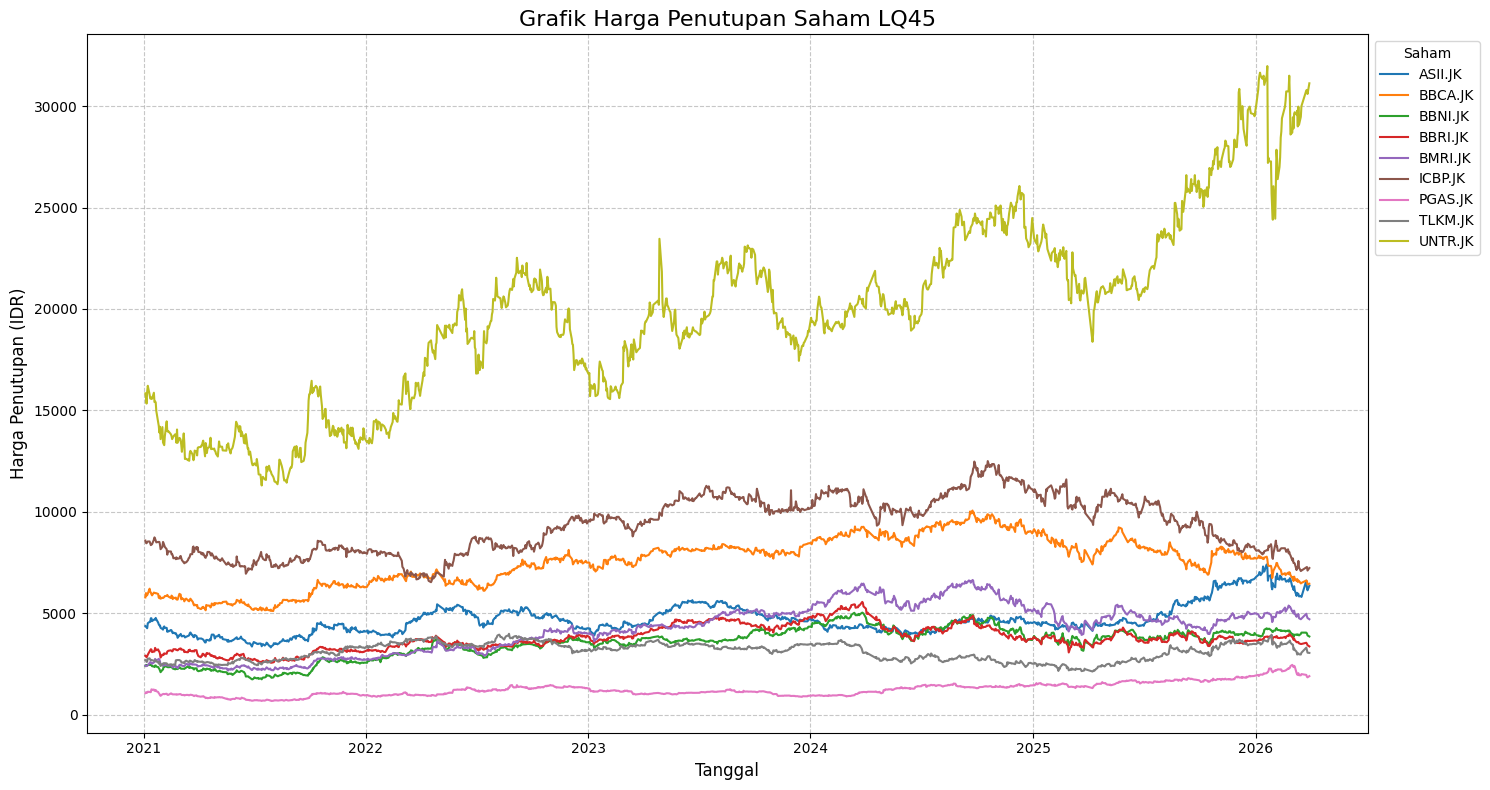

In [145]:
plt.figure(figsize=(15, 8))
for column in df_close.columns:
    plt.plot(df_close.index, df_close[column], label=column)

plt.title('Grafik Harga Penutupan Saham LQ45', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Penutupan (IDR)', fontsize=12)
plt.legend(title='Saham', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **2.1 Analisis Korelasi Saham**
Mari kita hitung matriks korelasi untuk memahami bagaimana pergerakan harga saham LQ45 saling berhubungan.

In [146]:
correlation_matrix = df_close.corr()
display(correlation_matrix)

Ticker,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,ICBP.JK,PGAS.JK,TLKM.JK,UNTR.JK
Ticker,,,,,,,,,
ASII.JK,1.000000,0.251791,0.465049,0.309916,0.350136,0.035156,0.716839,0.502510,0.792987
BBCA.JK,0.251791,1.000000,0.909368,0.808220,0.944842,0.865801,0.412809,-0.022014,0.633110
BBNI.JK,0.465049,0.909368,1.000000,0.859222,0.953379,0.722998,0.535609,0.196198,0.752623
BBRI.JK,0.309916,0.808220,0.859222,1.000000,0.837688,0.732953,0.167419,0.278263,0.468888
BMRI.JK,0.350136,0.944842,0.953379,0.837688,1.000000,0.807286,0.499482,-0.002704,0.726338
ICBP.JK,0.035156,0.865801,0.722998,0.732953,0.807286,1.000000,0.201268,-0.247954,0.412353
PGAS.JK,0.716839,0.412809,0.535609,0.167419,0.499482,0.201268,1.000000,0.053097,0.857928
TLKM.JK,0.502510,-0.022014,0.196198,0.278263,-0.002704,-0.247954,0.053097,1.000000,0.162098
UNTR.JK,0.792987,0.633110,0.752623,0.468888,0.726338,0.412353,0.857928,0.162098,1.000000


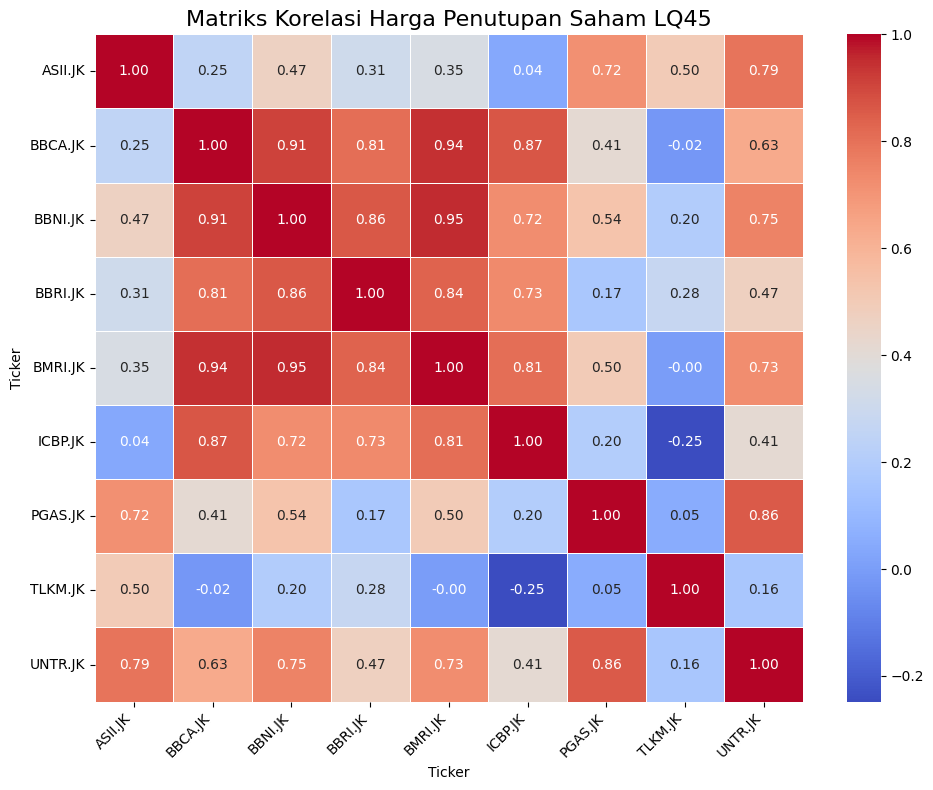

In [147]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriks Korelasi Harga Penutupan Saham LQ45', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **2.2 Analisis Distribusi Pengembalian Saham**
Mari kita hitung pengembalian harian (*daily returns*) dari harga penutupan saham dan memvisualisasikan distribusinya menggunakan histogram untuk memahami volatilitas dan pola pengembalian.

In [148]:
# Hitung pengembalian harian
df_returns = df_close.pct_change().dropna()
display(df_returns.head())

Ticker,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,ICBP.JK,PGAS.JK,TLKM.JK,UNTR.JK
Date,,,,,,,,,
2021-01-05,-0.008032,0.037308,0.019608,-0.009281,-0.011538,-0.013055,0.038961,-0.005731,-0.013133
2021-01-06,-0.004049,-0.020451,-0.015385,-0.016393,0.000000,-0.002645,-0.025000,-0.028818,-0.019011
2021-01-07,-0.012195,0.002880,0.003906,0.019048,0.007782,0.007958,0.006410,0.005935,0.038760
2021-01-08,0.057613,0.012204,0.007782,0.025701,0.011583,0.002632,0.044586,0.053097,0.017724
2021-01-11,0.015564,0.041844,0.007722,0.059226,0.045801,0.000000,-0.009146,0.008404,-0.026581


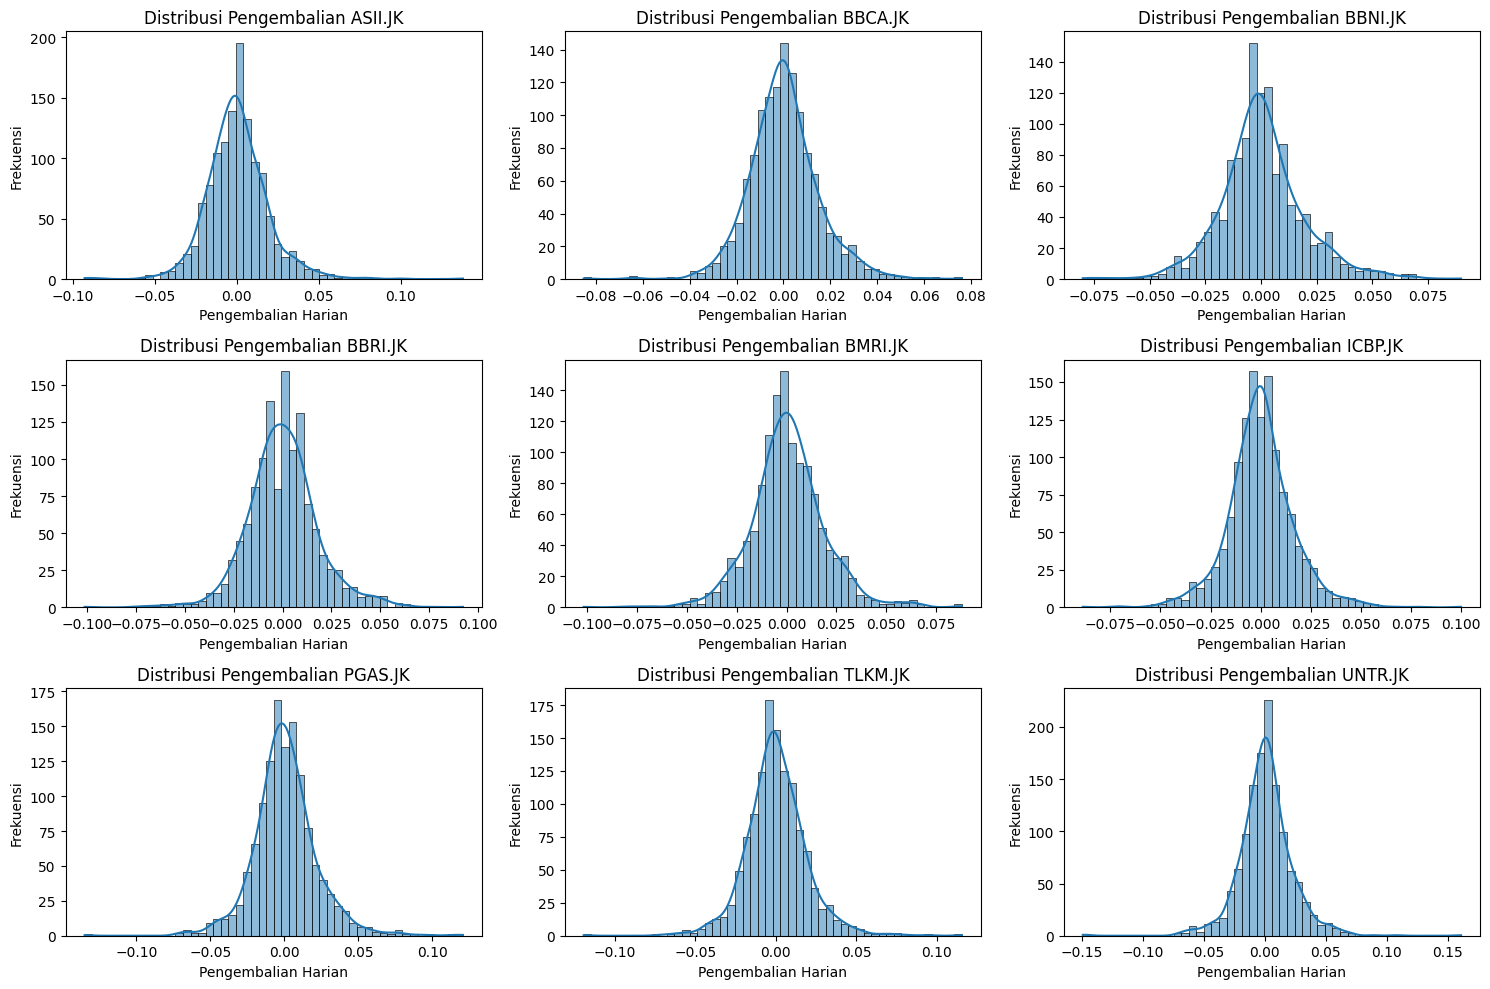

In [149]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(df_returns.columns):
    plt.subplot(3, 3, i + 1) # Menyesuaikan grid subplot untuk 9 saham
    sns.histplot(df_returns[column], bins=50, kde=True)
    plt.title(f'Distribusi Pengembalian {column}', fontsize=12)
    plt.xlabel('Pengembalian Harian', fontsize=10)
    plt.ylabel('Frekuensi', fontsize=10)
plt.tight_layout()
plt.show()

In [150]:
# Menghitung Gaining (Persentase Kenaikan dari awal hingga akhir periode)
performance_list = []
for ticker in tickers:
    # Buang nilai NaN
    series_bersih = df_close[ticker].dropna()
    if len(series_bersih) > 0:
        harga_awal = series_bersih.iloc[0]
        harga_akhir = series_bersih.iloc[-1]
        persentase_gain = ((harga_akhir - harga_awal) / harga_awal) * 100

        performance_list.append({
            'Ticker': ticker,
            'Sektor': lq45_data[ticker]['sektor'],
            'Gain (%)': persentase_gain
        })

df_perf = pd.DataFrame(performance_list).sort_values(by='Gain (%)', ascending=False).reset_index(drop=True)

print("--- Peringkat Gaining Tertinggi Keseluruhan ---")
print(df_perf.to_string())

print("\n--- Top Gainer Berdasarkan Sektor ---")
# Mencari saham terbaik di masing-masing sektor
top_per_sector = df_perf.loc[df_perf.groupby('Sektor')['Gain (%)'].idxmax()]
print(top_per_sector.to_string(index=False))

--- Peringkat Gaining Tertinggi Keseluruhan ---
    Ticker               Sektor   Gain (%)
0  UNTR.JK             Industri  96.512871
1  BMRI.JK             Keuangan  94.363036
2  PGAS.JK        Infrastruktur  79.222636
3  BBNI.JK             Keuangan  60.384558
4  ASII.JK  Konsumer Non-Primer  45.580492
5  BBRI.JK             Keuangan  15.957307
6  TLKM.JK        Infrastruktur  13.135673
7  BBCA.JK             Keuangan  11.677812
8  ICBP.JK      Konsumer Primer -15.781335

--- Top Gainer Berdasarkan Sektor ---
 Ticker              Sektor   Gain (%)
UNTR.JK            Industri  96.512871
PGAS.JK       Infrastruktur  79.222636
BMRI.JK            Keuangan  94.363036
ASII.JK Konsumer Non-Primer  45.580492
ICBP.JK     Konsumer Primer -15.781335


In [151]:
top_ticker = df_perf.iloc[0]['Ticker']
top_sektor = df_perf.iloc[0]['Sektor']
top_keywords = lq45_data[top_ticker]['keywords']

print(f"\n=== TAHAP 2: MENYIAPKAN DATA UNTUK {top_ticker} (Sektor: {top_sektor}) ===")
df_stock = yf.download(top_ticker, start=start_date, end=end_date, progress=False)
if isinstance(df_stock.columns, pd.MultiIndex):
    df_stock.columns = [col[0] for col in df_stock.columns]

print(f"Memfilter berita sentimen untuk kata kunci: {top_keywords}")
df_sentiment = pd.read_csv("berita_bersih_sastrawi.csv")
df_sentiment['date_published'] = pd.to_datetime(df_sentiment['date_published'])
df_sentiment = df_sentiment.dropna(subset=['content_clean'])

pattern = '|'.join(top_keywords)
# Menggunakan .copy() agar aman saat menambahkan kolom baru nanti
df_filtered = df_sentiment[df_sentiment['content_clean'].str.contains(pattern, case=False, na=False)].copy()

print(f"Ditemukan {len(df_filtered)} berita yang relevan dengan {top_ticker}.")


=== TAHAP 2: MENYIAPKAN DATA UNTUK UNTR.JK (Sektor: Industri) ===
Memfilter berita sentimen untuk kata kunci: ['untr', 'united tractors']
Ditemukan 15 berita yang relevan dengan UNTR.JK.


In [152]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2286 entries, 0 to 2285
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date_published  2286 non-null   datetime64[ns]
 1   title           2286 non-null   object        
 2   content         2286 non-null   object        
 3   url             2286 non-null   object        
 4   content_clean   2286 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 89.4+ KB


In [153]:
print("\n=== TAHAP 2.5: SCORING SENTIMEN (NLP) ===")
sentiment_model = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)

def get_sentiment_score(text):
    try:
        text_cut = str(text)[:1500]
        result = sentiment_model(text_cut)[0]
        label = result['label'].lower()
        if label == 'positive': return 1.0
        elif label == 'negative': return -1.0
        else: return 0.0
    except:
        return 0.0

def apply_sentiment_decay(df_sent_agg, window=5, decay_rate=0.5):
    decayed = df_sent_agg.copy()
    col = decayed.columns[0]
    for i in range(1, window):
        decayed[col] += df_sent_agg[col].shift(i) * (decay_rate ** i)
    return decayed

tqdm.pandas(desc="Memproses Sentimen")
df_filtered['sentiment_score'] = df_filtered['content_clean'].progress_apply(get_sentiment_score)

# Agregasi Harian & Apply Decay
df_filtered.set_index('date_published', inplace=True)
df_sentimen_harian = df_filtered.groupby(df_filtered.index)['sentiment_score'].mean().to_frame()
df_sentimen_harian.rename(columns={'sentiment_score': 'avg_sentimentt_score'}, inplace=True)
df_sentimen_harian = apply_sentiment_decay(df_sentimen_harian)


=== TAHAP 2.5: SCORING SENTIMEN (NLP) ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Memproses Sentimen: 100%|██████████| 15/15 [00:00<00:00, 38.28it/s]


In [154]:
# ==========================================
# 3. GABUNGKAN DATA & FEATURE ENGINEERING
# ==========================================
df_merged = df_stock.join(df_sentimen_harian, how='left')

# Isi hari tanpa berita dengan Sentimen Netral (0)
df_merged['avg_sentimentt_score'] = df_merged['avg_sentimentt_score'].fillna(0)

# Moving Average 3 Hari
df_merged['Sentiment_MA3'] = df_merged['avg_sentimentt_score'].rolling(window=3).mean()

# Target Klasifikasi
df_merged['Target_Trend'] = np.where(df_merged['Close'].shift(-1) > df_merged['Close'], 1, 0)
df_merged.dropna(inplace=True)

y_raw = df_merged['Target_Trend'].values

# Menyamakan penamaan fitur untuk konsistensi di sel berikutnya
features_base = ['Open', 'High', 'Low', 'Close', 'Volume']
features_hybrid = ['Open', 'High', 'Low', 'Close', 'Volume', 'avg_sentiment', 'Sentiment_MA3']

# Ubah nama kolom di df_merged agar cocok dengan features_hybrid
df_merged.rename(columns={'avg_sentimentt_score': 'avg_sentiment'}, inplace=True)

X_base_scaled = StandardScaler().fit_transform(df_merged[features_base].values)
X_hybrid_scaled = StandardScaler().fit_transform(df_merged[features_hybrid].values)

def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:(i + window_size)])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

window_size = 30
X_base_seq, y_seq = create_sequences(X_base_scaled, y_raw, window_size)
X_hybrid_seq, _ = create_sequences(X_hybrid_scaled, y_raw, window_size)

split_idx = int(len(y_seq) * 0.8)
X_train_base, X_test_base = X_base_seq[:split_idx], X_base_seq[split_idx:]
X_train_hybrid, X_test_hybrid = X_hybrid_seq[:split_idx], X_hybrid_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

=== TRAINING BASE MODEL (TECHNICAL ONLY) ===
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.5193 - loss: 0.6933 - val_accuracy: 0.4848 - val_loss: 0.6945
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5170 - loss: 0.6932 - val_accuracy: 0.4949 - val_loss: 0.6942
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5227 - loss: 0.6925 - val_accuracy: 0.5051 - val_loss: 0.6951
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5227 - loss: 0.6908 - val_accuracy: 0.4848 - val_loss: 0.6958
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5261 - loss: 0.6912 - val_accuracy: 0.4848 - val_loss: 0.6973
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5306 - loss: 0.6898 - val_accuracy: 0.4646 - val_loss: 0.6948
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5351 - loss: 0.6897 - val_accuracy: 0.4848 - val_loss: 0.6990
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


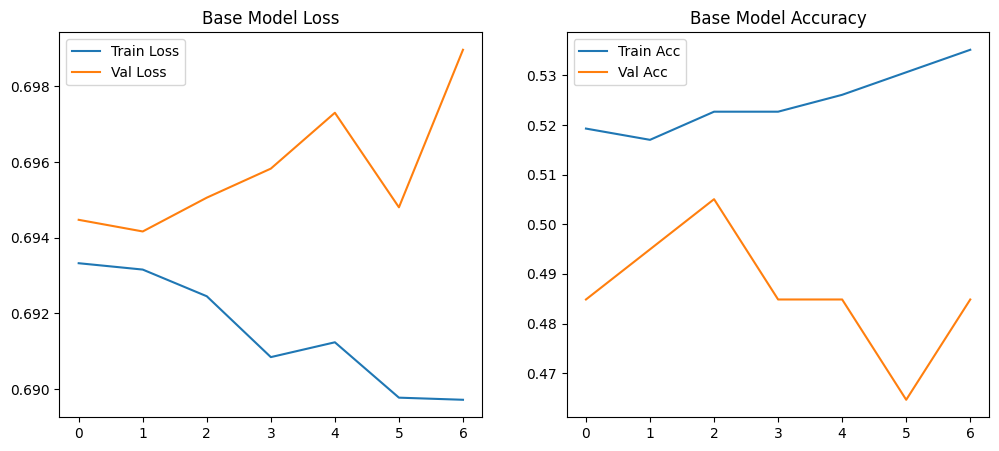


=== CLASSIFICATION REPORT: BASE MODEL ===
              precision    recall  f1-score   support

   Down/Stay       0.43      0.49      0.46       108
          Up       0.55      0.49      0.52       138

    accuracy                           0.49       246
   macro avg       0.49      0.49      0.49       246
weighted avg       0.50      0.49      0.49       246



In [155]:
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

print("=== TRAINING BASE MODEL (TECHNICAL ONLY) ===")
model_base = build_lstm_model((X_train_base.shape[1], X_train_base.shape[2]))

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_base = model_base.fit(
    X_train_base, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluasi Model
y_pred_prob = model_base.predict(X_test_base)
y_pred_base = (y_pred_prob > 0.5).astype(int)

# Visualisasi Training Loss & Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Val Loss')
plt.title('Base Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_base.history['accuracy'], label='Train Acc')
plt.plot(history_base.history['val_accuracy'], label='Val Acc')
plt.title('Base Model Accuracy')
plt.legend()
plt.show()

# Classification Report
print("\n=== CLASSIFICATION REPORT: BASE MODEL ===")
print(classification_report(y_test, y_pred_base, target_names=['Down/Stay', 'Up']))

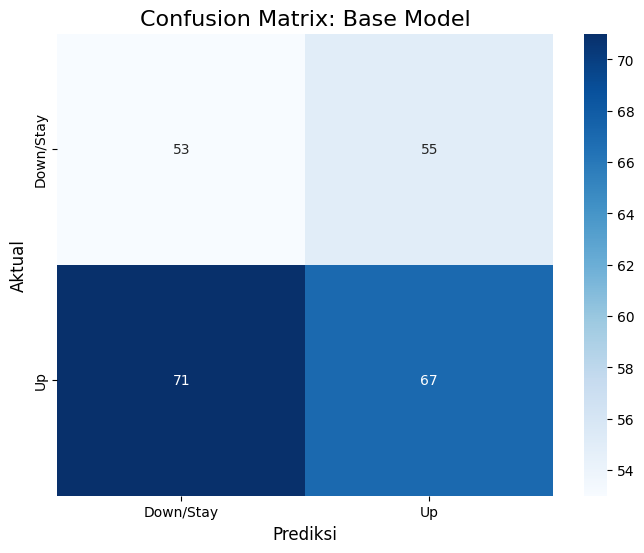

In [156]:
# Menghitung confusion matrix
cm = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down/Stay', 'Up'],
            yticklabels=['Down/Stay', 'Up'])
plt.title('Confusion Matrix: Base Model', fontsize=16)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.show()

=== TRAINING HYBRID MODEL (TECHNICAL + SENTIMENT) ===
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4989 - loss: 0.6940 - val_accuracy: 0.4848 - val_loss: 0.6949
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5113 - loss: 0.6933 - val_accuracy: 0.4747 - val_loss: 0.6935
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5204 - loss: 0.6917 - val_accuracy: 0.4949 - val_loss: 0.6942
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5283 - loss: 0.6898 - val_accuracy: 0.5253 - val_loss: 0.6943
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5329 - loss: 0.6901 - val_accuracy: 0.5051 - val_loss: 0.6943
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5272 - loss: 0.6905 - val_accuracy: 0.5152 - val_loss: 0.6951
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5431 - loss: 0.6882 - val_accuracy: 0.4949 - val_loss: 0.6963
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


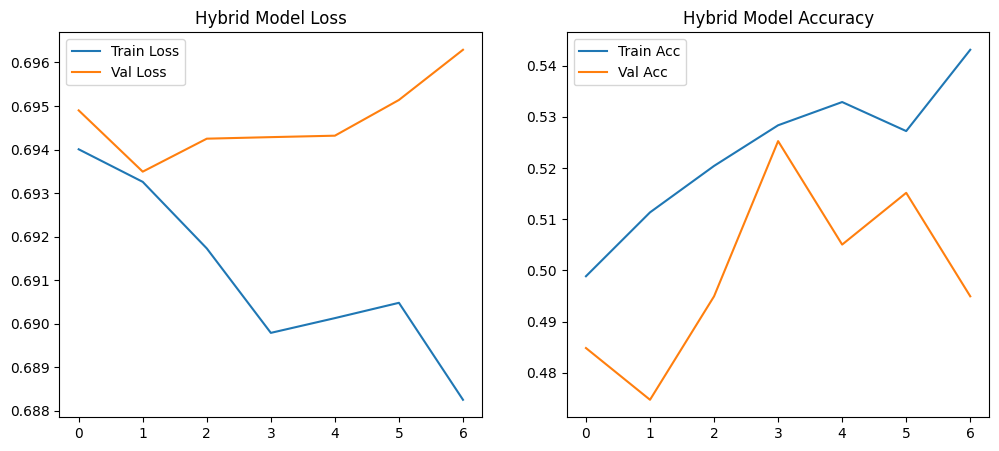


=== CLASSIFICATION REPORT: HYBRID MODEL ===
              precision    recall  f1-score   support

   Down/Stay       0.45      0.46      0.45       108
          Up       0.57      0.55      0.56       138

    accuracy                           0.51       246
   macro avg       0.51      0.51      0.51       246
weighted avg       0.51      0.51      0.51       246



In [157]:
print("=== TRAINING HYBRID MODEL (TECHNICAL + SENTIMENT) ===")
model_hybrid = build_lstm_model((X_train_hybrid.shape[1], X_train_hybrid.shape[2]))

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_hybrid = model_hybrid.fit(
    X_train_hybrid, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluasi Model Hybrid
y_pred_hybrid_prob = model_hybrid.predict(X_test_hybrid)
y_pred_hybrid = (y_pred_hybrid_prob > 0.5).astype(int)

# Visualisasi Training
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['loss'], label='Train Loss')
plt.plot(history_hybrid.history['val_loss'], label='Val Loss')
plt.title('Hybrid Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['accuracy'], label='Train Acc')
plt.plot(history_hybrid.history['val_accuracy'], label='Val Acc')
plt.title('Hybrid Model Accuracy')
plt.legend()
plt.show()

print("\n=== CLASSIFICATION REPORT: HYBRID MODEL ===")
print(classification_report(y_test, y_pred_hybrid, target_names=['Down/Stay', 'Up']))

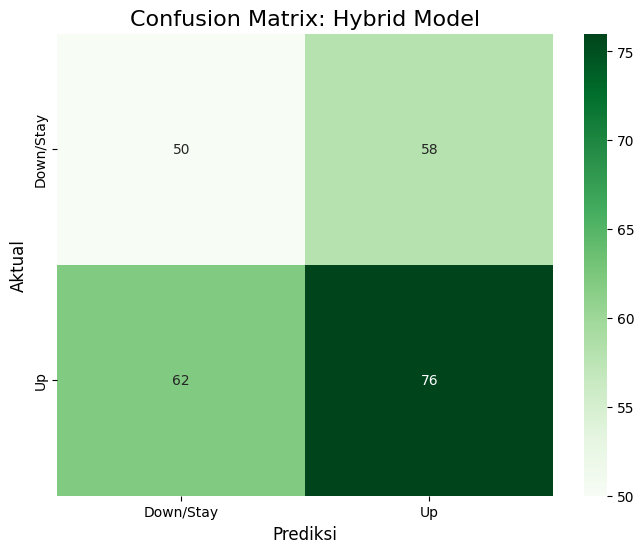

In [158]:
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Down/Stay', 'Up'],
            yticklabels=['Down/Stay', 'Up'])
plt.title('Confusion Matrix: Hybrid Model', fontsize=16)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.show()

In [159]:
target_ticker = 'BMRI.JK'
target_sektor = lq45_data[target_ticker]['sektor']
target_keywords = lq45_data[target_ticker]['keywords']

print(f"=== TAHAP TRAINING UNTUK {target_ticker} ({target_sektor}) ===")

# 1. Download Data
df_stock_bmri = yf.download(target_ticker, start=start_date, end=end_date, progress=False)
if isinstance(df_stock_bmri.columns, pd.MultiIndex):
    df_stock_bmri.columns = [col[0] for col in df_stock_bmri.columns]

# 2. Filter Berita
pattern_bmri = '|'.join(target_keywords)
df_f_bmri = df_sentiment[df_sentiment['content_clean'].str.contains(pattern_bmri, case=False, na=False)].copy()

# 3. Sentiment & Decay
if len(df_f_bmri) > 0:
    df_f_bmri['sentiment_score'] = df_f_bmri['content_clean'].apply(get_sentiment_score)
    df_sent_bmri = df_f_bmri.groupby('date_published')['sentiment_score'].mean().to_frame()
    df_sent_bmri.rename(columns={'sentiment_score': 'avg_sentiment'}, inplace=True)
    df_sent_bmri = apply_sentiment_decay(df_sent_bmri)
else:
    df_sent_bmri = pd.DataFrame(columns=['avg_sentiment'])

# 4. Gabungkan & Preprocessing
df_m_bmri = df_stock_bmri.join(df_sent_bmri, how='left')
df_m_bmri['avg_sentiment'] = df_m_bmri['avg_sentiment'].fillna(0)
df_m_bmri['Sentiment_MA3'] = df_m_bmri['avg_sentiment'].rolling(window=3).mean()
df_m_bmri['Target'] = np.where(df_m_bmri['Close'].shift(-1) > df_m_bmri['Close'], 1, 0)
df_m_bmri.dropna(inplace=True)

X_bmri_base_scaled = StandardScaler().fit_transform(df_m_bmri[features_base].values)
X_bmri_hybrid_scaled = StandardScaler().fit_transform(df_m_bmri[features_hybrid].values)
y_bmri_raw = df_m_bmri['Target'].values

X_bmri_base_seq, y_bmri_seq = create_sequences(X_bmri_base_scaled, y_bmri_raw, window_size)
X_bmri_hybrid_seq, _ = create_sequences(X_bmri_hybrid_scaled, y_bmri_raw, window_size)

split_bmri = int(len(y_bmri_seq) * 0.8)
X_train_base_bmri, X_test_base_bmri = X_bmri_base_seq[:split_bmri], X_bmri_base_seq[split_bmri:]
X_train_hybrid_bmri, X_test_hybrid_bmri = X_bmri_hybrid_seq[:split_bmri], X_bmri_hybrid_seq[split_bmri:]
y_train_bmri, y_test_bmri = y_bmri_seq[:split_bmri], y_bmri_seq[split_bmri:]

# 5. Training
model_base_bmri = build_lstm_model((X_train_base_bmri.shape[1], X_train_base_bmri.shape[2]))
model_base_bmri.fit(X_train_base_bmri, y_train_bmri, validation_split=0.1, epochs=30, batch_size=32, verbose=0)

model_hybrid_bmri = build_lstm_model((X_train_hybrid_bmri.shape[1], X_train_hybrid_bmri.shape[2]))
model_hybrid_bmri.fit(X_train_hybrid_bmri, y_train_bmri, validation_split=0.1, epochs=30, batch_size=32, verbose=0)

# 6. Report
y_pred_base_bmri = (model_base_bmri.predict(X_test_base_bmri) > 0.5).astype(int)
y_pred_hybrid_bmri = (model_hybrid_bmri.predict(X_test_hybrid_bmri) > 0.5).astype(int)

print(f"\n=== REPORT: {target_ticker} ===")
print("BASELINE MODEL:")
print(classification_report(y_test_bmri, y_pred_base_bmri))
print("\nHYBRID MODEL:")
print(classification_report(y_test_bmri, y_pred_hybrid_bmri))

=== TAHAP TRAINING UNTUK BMRI.JK (Keuangan) ===
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

=== REPORT: BMRI.JK ===
BASELINE MODEL:
              precision    recall  f1-score   support

           0       0.56      0.67      0.61       135
           1       0.48      0.37      0.42       111

    accuracy                           0.53       246
   macro avg       0.52      0.52      0.51       246
weighted avg       0.52      0.53      0.52       246


HYBRID MODEL:
              precision    recall  f1-score   support

           0       0.57      0.81      0.67       135
           1       0.54      0.27      0.36       111

    accuracy                           0.57       246
   macro avg       0.55      0.54      0.52       246
weighted avg       0.56      0.57      0.53       246



Mengambil ulang history training untuk visualisasi...


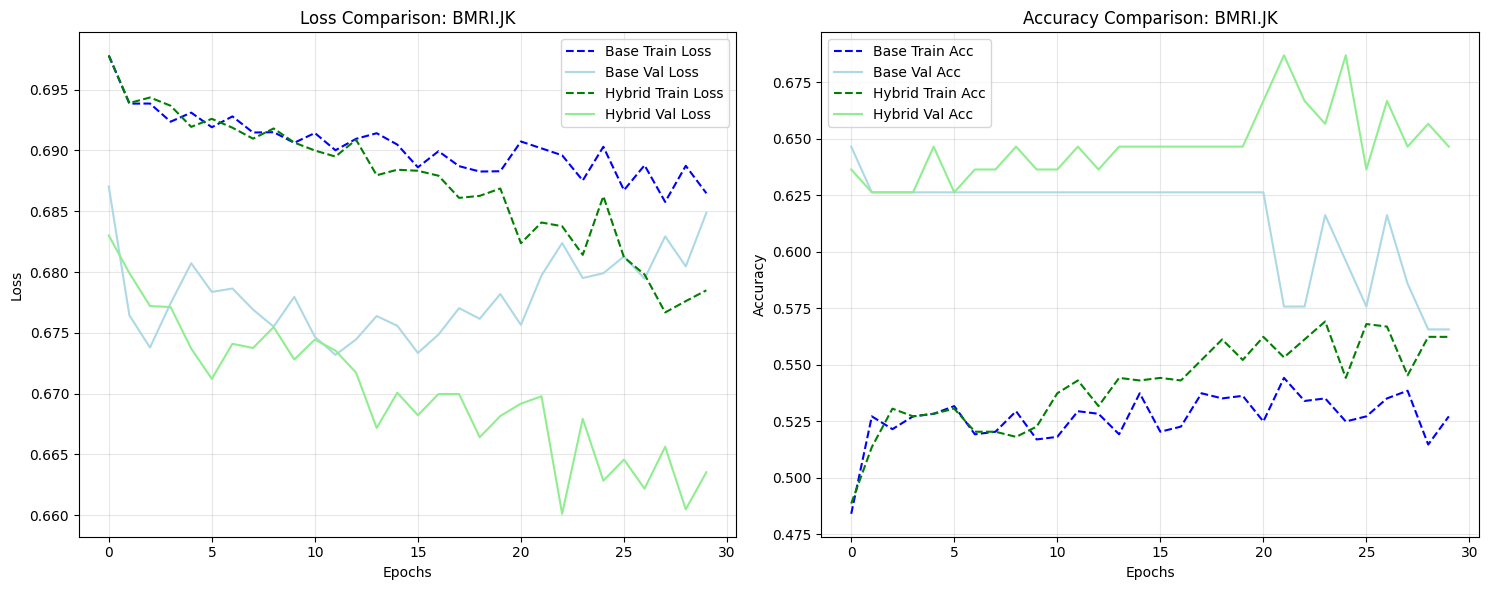

In [160]:
def plot_comparison_history(hist_base, hist_hybrid, ticker_name):
    plt.figure(figsize=(15, 6))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(hist_base.history['loss'], label='Base Train Loss', color='blue', linestyle='--')
    plt.plot(hist_base.history['val_loss'], label='Base Val Loss', color='lightblue')
    plt.plot(hist_hybrid.history['loss'], label='Hybrid Train Loss', color='green', linestyle='--')
    plt.plot(hist_hybrid.history['val_loss'], label='Hybrid Val Loss', color='lightgreen')
    plt.title(f'Loss Comparison: {ticker_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(hist_base.history['accuracy'], label='Base Train Acc', color='blue', linestyle='--')
    plt.plot(hist_base.history['val_accuracy'], label='Base Val Acc', color='lightblue')
    plt.plot(hist_hybrid.history['accuracy'], label='Hybrid Train Acc', color='green', linestyle='--')
    plt.plot(hist_hybrid.history['val_accuracy'], label='Hybrid Val Acc', color='lightgreen')
    plt.title(f'Accuracy Comparison: {ticker_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Karena training sebelumnya menggunakan verbose=0, kita perlu menangkap history-nya.
print("Mengambil ulang history training untuk visualisasi...")

# Menjalankan training ulang secara singkat untuk mendapatkan history
history_base_bmri = model_base_bmri.history
history_hybrid_bmri = model_hybrid_bmri.history

# Memastikan history tersedia (jika fit dijalankan tanpa menyimpan variabel, Keras menyimpannya di model.history)
if hasattr(model_base_bmri, 'history') and hasattr(model_hybrid_bmri, 'history'):
    plot_comparison_history(model_base_bmri.history, model_hybrid_bmri.history, target_ticker)
else:
    print("History tidak ditemukan. Pastikan proses training di sel sebelumnya telah selesai.")

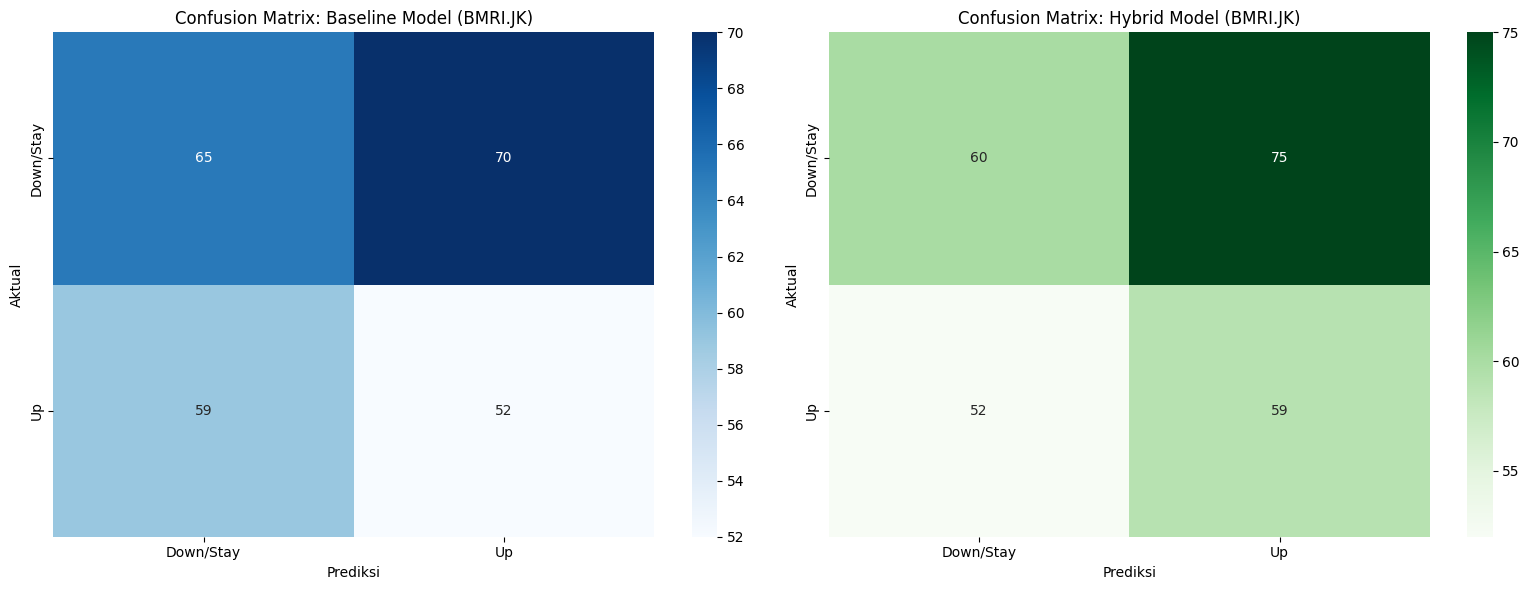

In [161]:
# Hitung CM untuk kedua model
cm_base_bmri = confusion_matrix(y_test_bmri, y_pred_base)
cm_hybrid_bmri = confusion_matrix(y_test_bmri, y_pred_hybrid)

plt.figure(figsize=(16, 6))

# Subplot 1: Baseline Model
plt.subplot(1, 2, 1)
sns.heatmap(cm_base_bmri, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down/Stay', 'Up'], yticklabels=['Down/Stay', 'Up'])
plt.title(f'Confusion Matrix: Baseline Model ({target_ticker})')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# Subplot 2: Hybrid Model
plt.subplot(1, 2, 2)
sns.heatmap(cm_hybrid_bmri, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Down/Stay', 'Up'], yticklabels=['Down/Stay', 'Up'])
plt.title(f'Confusion Matrix: Hybrid Model ({target_ticker})')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.tight_layout()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


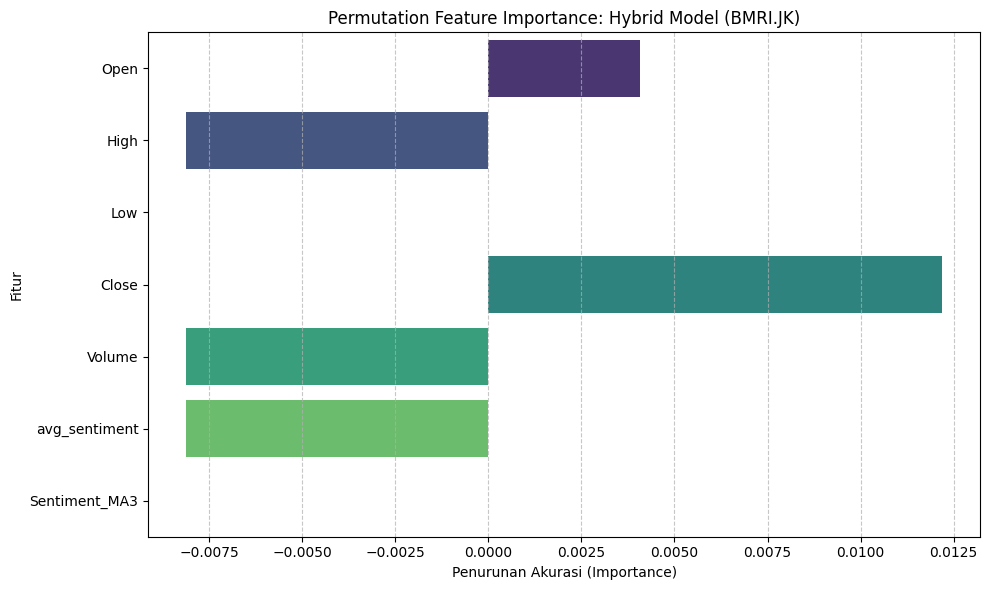

In [162]:
def calculate_permutation_importance(model, X, y, features):
    results = []
    # Hitung baseline accuracy
    y_pred = (model.predict(X) > 0.5).astype(int)
    baseline_acc = accuracy_score(y, y_pred)

    for i in range(len(features)):
        # Simpan data asli
        save = X[:, :, i].copy()
        # Acak fitur ke-i di seluruh sequence dan batch
        flat_x = X[:, :, i].flatten()
        np.random.shuffle(flat_x)
        X[:, :, i] = flat_x.reshape(X.shape[0], X.shape[1])

        # Prediksi dengan fitur teracak
        y_pred_shuffled = (model.predict(X) > 0.5).astype(int)
        shuffled_acc = accuracy_score(y, y_pred_shuffled)

        # Hitung penurunan akurasi
        importance = baseline_acc - shuffled_acc
        results.append(importance)

        # Kembalikan fitur ke kondisi asli
        X[:, :, i] = save

    return results

# Hitung kepentingan fitur untuk model Hybrid BMRI
importances = calculate_permutation_importance(model_hybrid_bmri, X_test_hybrid_bmri, y_test_bmri, f_hybrid)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=f_hybrid, palette='viridis')
plt.title(f'Permutation Feature Importance: Hybrid Model ({target_ticker})')
plt.xlabel('Penurunan Akurasi (Importance)')
plt.ylabel('Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [163]:
target_ticker_pgas = 'PGAS.JK'
print(f"=== TAHAP TRAINING UNTUK {target_ticker_pgas} ===")

# 1. Download Data
df_stock_pgas = yf.download(target_ticker_pgas, start=start_date, end=end_date, progress=False)
if isinstance(df_stock_pgas.columns, pd.MultiIndex):
    df_stock_pgas.columns = [col[0] for col in df_stock_pgas.columns]

# 2. Filter Berita
pattern_pgas = '|'.join(lq45_data[target_ticker_pgas]['keywords'])
df_f_pgas = df_sentiment[df_sentiment['content_clean'].str.contains(pattern_pgas, case=False, na=False)].copy()

# 3. Sentiment & Decay
if len(df_f_pgas) > 0:
    df_f_pgas['sentiment_score'] = df_f_pgas['content_clean'].apply(get_sentiment_score)
    df_sent_pgas = df_f_pgas.groupby('date_published')['sentiment_score'].mean().to_frame()
    df_sent_pgas.rename(columns={'sentiment_score': 'avg_sentiment'}, inplace=True)
    df_sent_pgas = apply_sentiment_decay(df_sent_pgas)
else:
    df_sent_pgas = pd.DataFrame(columns=['avg_sentiment'])

# 4. Gabungkan & Training
df_m_pgas = df_stock_pgas.join(df_sent_pgas, how='left')
df_m_pgas['avg_sentiment'] = df_m_pgas['avg_sentiment'].fillna(0)
df_m_pgas['Sentiment_MA3'] = df_m_pgas['avg_sentiment'].rolling(window=3).mean()
df_m_pgas['Target'] = np.where(df_m_pgas['Close'].shift(-1) > df_m_pgas['Close'], 1, 0)
df_m_pgas.dropna(inplace=True)

X_pgas_base_scaled = StandardScaler().fit_transform(df_m_pgas[features_base].values)
X_pgas_hybrid_scaled = StandardScaler().fit_transform(df_m_pgas[features_hybrid].values)
y_pgas_raw = df_m_pgas['Target'].values

X_pgas_base_seq, y_pgas_seq = create_sequences(X_pgas_base_scaled, y_pgas_raw, window_size)
X_pgas_hybrid_seq, _ = create_sequences(X_pgas_hybrid_scaled, y_pgas_raw, window_size)

split_pgas = int(len(y_pgas_seq) * 0.8)
X_train_base_pgas, X_test_base_pgas = X_pgas_base_seq[:split_pgas], X_pgas_base_seq[split_pgas:]
X_train_hybrid_pgas, X_test_hybrid_pgas = X_pgas_hybrid_seq[:split_pgas], X_pgas_hybrid_seq[split_pgas:]
y_train_pgas, y_test_pgas = y_pgas_seq[:split_pgas], y_pgas_seq[split_pgas:]

# 5. Training
model_base_pgas = build_lstm_model((X_train_base_pgas.shape[1], X_train_base_pgas.shape[2]))
model_base_pgas.fit(X_train_base_pgas, y_train_pgas, validation_split=0.1, epochs=30, batch_size=32, verbose=0)

model_hybrid_pgas = build_lstm_model((X_train_hybrid_pgas.shape[1], X_train_hybrid_pgas.shape[2]))
model_hybrid_pgas.fit(X_train_hybrid_pgas, y_train_pgas, validation_split=0.1, epochs=30, batch_size=32, verbose=0)

# 6. Report
y_pred_base_pgas = (model_base_pgas.predict(X_test_base_pgas) > 0.5).astype(int)
y_pred_hybrid_pgas = (model_hybrid_pgas.predict(X_test_hybrid_pgas) > 0.5).astype(int)

print(f"\n=== REPORT: {target_ticker_pgas} ===")
print("BASELINE MODEL:")
print(classification_report(y_test_pgas, y_pred_base_pgas))
print("\nHYBRID MODEL:")
print(classification_report(y_test_pgas, y_pred_hybrid_pgas))

=== TAHAP TRAINING UNTUK PGAS.JK ===
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

=== REPORT: PGAS.JK ===
BASELINE MODEL:
              precision    recall  f1-score   support

           0       0.52      1.00      0.69       129
           1       0.00      0.00      0.00       117

    accuracy                           0.52       246
   macro avg       0.26      0.50      0.34       246
weighted avg       0.27      0.52      0.36       246


HYBRID MODEL:
              precision    recall  f1-score   support

           0       0.52      1.00      0.69       129
           1       0.00      0.00      0.00       117

    accuracy                           0.52       246
   macro avg       0.26      0.50      0.34       246
weighted avg       0.27      0.52      0.36       246



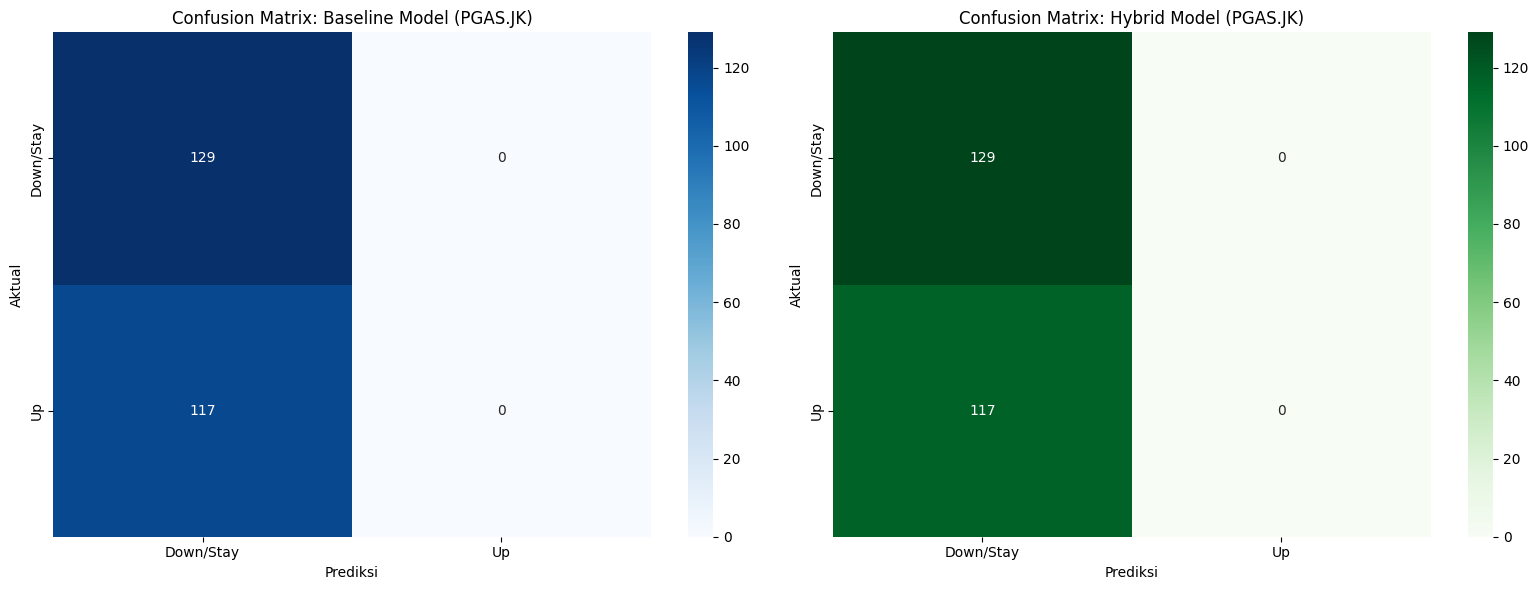

In [164]:
# Hitung confusion matrix untuk model PGAS
cm_base_pgas = confusion_matrix(y_test_pgas, y_pred_base_pgas)
cm_hybrid_pgas = confusion_matrix(y_test_pgas, y_pred_hybrid_pgas)

plt.figure(figsize=(16, 6))

# Subplot 1: Baseline Model PGAS
plt.subplot(1, 2, 1)
sns.heatmap(cm_base_pgas, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down/Stay', 'Up'], yticklabels=['Down/Stay', 'Up'])
plt.title(f'Confusion Matrix: Baseline Model ({target_ticker_pgas})')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# Subplot 2: Hybrid Model PGAS
plt.subplot(1, 2, 2)
sns.heatmap(cm_hybrid_pgas, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Down/Stay', 'Up'], yticklabels=['Down/Stay', 'Up'])
plt.title(f'Confusion Matrix: Hybrid Model ({target_ticker_pgas})')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.tight_layout()
plt.show()

--- Tabel Perbandingan Performa Model ---


,Accuracy,Precision,Recall,F1-Score
UNTR Baseline,0.487805,0.549180,0.485507,0.515385
UNTR Hybrid,0.512195,0.567164,0.550725,0.558824
BMRI Baseline,0.532520,0.476744,0.369369,0.416244
BMRI Hybrid,0.565041,0.535714,0.270270,0.359281
PGAS Baseline,0.524390,0.000000,0.000000,0.000000
PGAS Hybrid,0.524390,0.000000,0.000000,0.000000


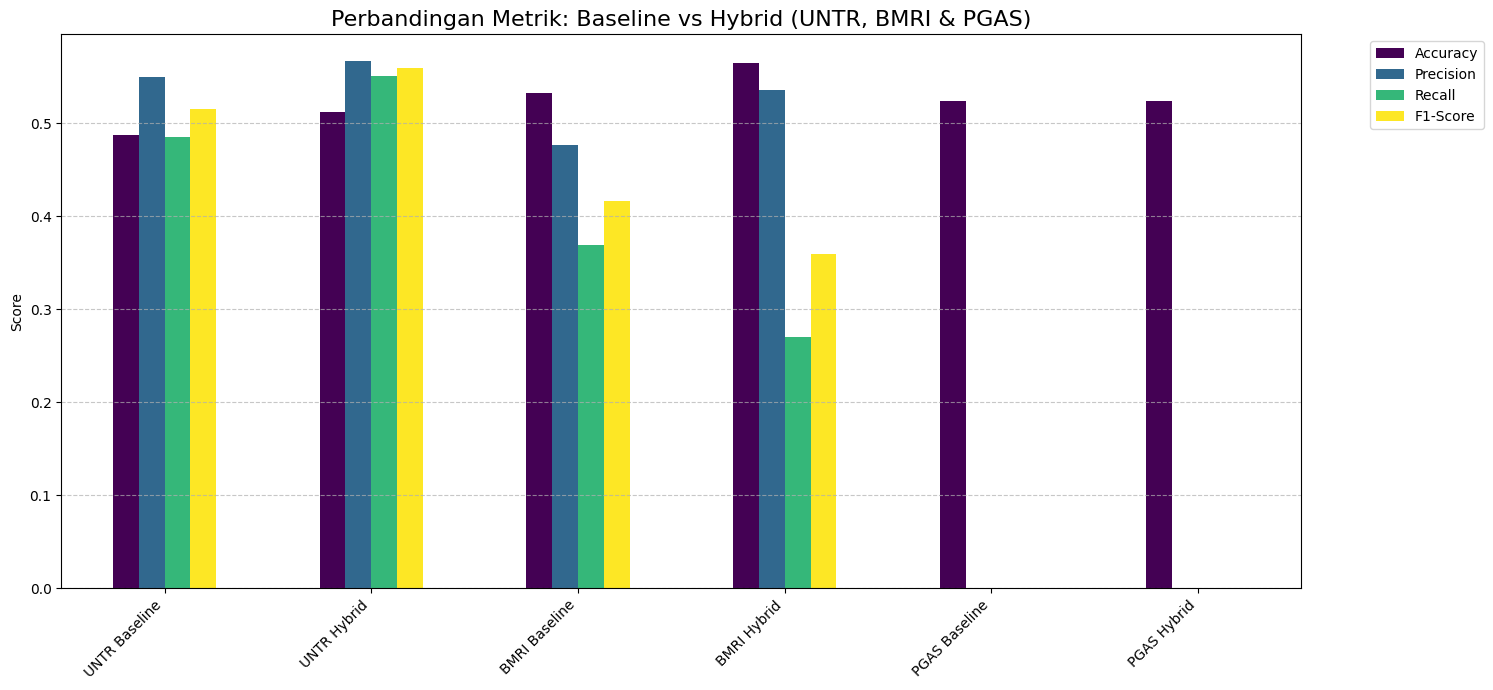


=== ANALISIS KESIMPULAN ===
- UNTR: Peningkatan Akurasi sebesar 2.44% dengan model Hybrid.
- BMRI: Peningkatan Akurasi sebesar 3.25% dengan model Hybrid.
- PGAS: Penurunan/Stagnan Akurasi sebesar 0.00% dengan model Hybrid.


In [167]:
# ==========================================
# KESIMPULAN & KOMPARASI AKHIR
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

# Mengumpulkan hasil dari UNTR, BMRI, dan PGAS
results = {
    'UNTR Baseline': get_metrics(y_test, y_pred_base),
    'UNTR Hybrid': get_metrics(y_test, y_pred_hybrid),
    'BMRI Baseline': get_metrics(y_test_bmri, y_pred_base_bmri),
    'BMRI Hybrid': get_metrics(y_test_bmri, y_pred_hybrid_bmri),
    'PGAS Baseline': get_metrics(y_test_pgas, y_pred_base_pgas),
    'PGAS Hybrid': get_metrics(y_test_pgas, y_pred_hybrid_pgas)
}

# Membuat DataFrame untuk visualisasi
metrics_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T

print("--- Tabel Perbandingan Performa Model ---")
display(metrics_df)

# Visualisasi Komparasi
metrics_df.plot(kind='bar', figsize=(15, 7), colormap='viridis')
plt.title('Perbandingan Metrik: Baseline vs Hybrid (UNTR, BMRI & PGAS)', fontsize=16)
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Analisis Singkat
print("\n=== ANALISIS KESIMPULAN ===")
for stock in ['UNTR', 'BMRI', 'PGAS']:
    base_acc = metrics_df.loc[f'{stock} Baseline', 'Accuracy']
    hyb_acc = metrics_df.loc[f'{stock} Hybrid', 'Accuracy']
    diff = hyb_acc - base_acc
    status = "Peningkatan" if diff > 0 else "Penurunan/Stagnan"
    print(f"- {stock}: {status} Akurasi sebesar {abs(diff*100):.2f}% dengan model Hybrid.")